# Imports

In [4]:
# !pip install -U scikit-learn scipy matplotlib
# !pip install tqdm

import tensorflow as tf

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

import collections
import random
import re
import numpy as np
import os
import time
import json
from glob import glob
from PIL import Image
import pickle
from tqdm import tqdm

import zipfile


# Loading data

In [5]:
# Path to the annotation file
annotation_folder = os.path.abspath('.') + "/MS_COCO/annotations/"
annotation_file = annotation_folder + "captions_train2014.json"

print("annotation_folder", annotation_folder)
print("annotation_file", annotation_file)

# Path to the folder containing images to annotate
image_folder = '/MS_COCO/train2014/'
PATH = os.path.abspath('.') + image_folder

print("the path PATH", PATH)

annotation_folder c:\Users\P3mas\Projects\TouNum/MS_COCO/annotations/
annotation_file c:\Users\P3mas\Projects\TouNum/MS_COCO/annotations/captions_train2014.json
the path PATH c:\Users\P3mas\Projects\TouNum/MS_COCO/train2014/


In [6]:
with open(annotation_folder + "/captions_val2014.json", 'r') as f:
    annotations = json.load(f)

with open(annotation_folder + "instances_val2014.json", 'r') as f:
    instances = json.load(f)

In [7]:
# Reading the annotation file
with open(annotation_file, 'r') as f:
    annotations = json.load(f)

# Group all annotations having the same ID.
image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
    # mark the beginning and end of each annotation
    caption = f"<start> {val['caption']} <end>"
    # The ID of an image is part of its access path
    image_path = PATH + 'COCO_train2014_' + '%012d.jpg' % (val['image_id'])
    # Add the caption associated with image_path
    image_path_to_caption[image_path].append(caption)

In [8]:
# Take only the first images
image_paths = list(image_path_to_caption.keys())
random.shuffle(image_paths)
train_image_paths = image_paths[:10000]
print(len(train_image_paths))


10000


On affiche un example d'image et de ses annotations

In [9]:
# List of all annotations
train_captions = []
# List of all image filenames duplicated (as many times as annotations per image)
img_name_vector = []

for image_path in train_image_paths:
    caption_list = image_path_to_caption[image_path]
    # Add caption_list to train_captions
    train_captions.extend(caption_list)
    # Add image_path duplicated len(caption_list) times
    img_name_vector.extend([image_path] * len(caption_list))


50017 50017
<start> A cow grazing on lush green grass in a field. <end>


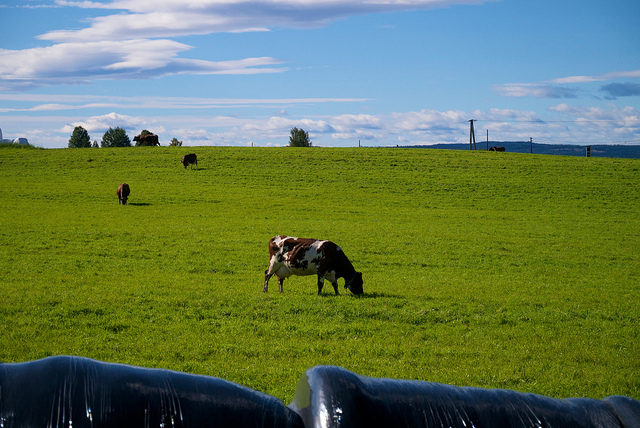

In [10]:
print(len(train_captions), len(img_name_vector))
print(train_captions[0])
Image.open(img_name_vector[0])

# 2 Pre-treat datas

In [11]:
# Downloading the pre-trained InceptionV3 model trained on ImageNet for classification
image_model = tf.keras.applications.InceptionV3(include_top=False,
                                                weights='imagenet')
# Creating a variable that will be the input of the new image pre-processing model
new_input = image_model.input
# Retrieve the last hidden layer which contains the image in a compact representation
hidden_layer = image_model.layers[-1].output

# Model that computes a dense representation of images using InceptionV3
image_features_extract_model = tf.keras.Model(new_input, hidden_layer)


In [12]:
def load_image(image_path):
    """
    The load_image function takes the path of an image as input and returns a tuple
    containing the processed image and its access path.
    The load_image function performs the following steps:
        1. Load the file corresponding to the image_path.
        2. Decode the image in RGB.
        3. Resize the image to size (299, 299).
        4. Normalize the image pixels between -1 and 1.
    """
    # Read the image file
    img = tf.io.read_file(image_path)
    # Decode the image in RGB
    img = tf.image.decode_jpeg(img, channels=3)
    # Resize the image to size (299, 299)
    img = tf.image.resize(img, (299, 299))
    # Normalize the image pixels between -1 and 1
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path


In [13]:
from tqdm import tqdm

# Image preprocessing
# Get the image filenames
encode_train = sorted(set(img_name_vector))

# Create an instance of "tf.data.Dataset" from the image filenames
image_dataset = tf.data.Dataset.from_tensor_slices(encode_train)
# Split the data into batches after applying the preprocessing done by load_image
image_dataset = image_dataset.map(
    load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE).batch(16)

# Iterate through the dataset batch by batch to apply InceptionV3 preprocessing
for img, path in tqdm(image_dataset):
    # Preprocess the current batch (of size (16,8,8,2048)) with InceptionV3
    batch_features = image_features_extract_model(img)
    # Resize the batch from size (16,8,8,2048) to size (16,64,2048)
    batch_features = tf.reshape(batch_features,
                                (batch_features.shape[0], -1, batch_features.shape[3]))
    # Loop through the current batch and save the path and the batch using np.save()
    for bf, p in zip(batch_features, path):
        path_of_feature = p.numpy().decode("utf-8")
        # (image path associated with its new representation, image representation)
        np.save(
            path_of_feature, bf.numpy()
        )


  6%|▌         | 38/625 [00:47<12:13,  1.25s/it]


KeyboardInterrupt: 

# 3 Pre-treatment of annotations

In [ ]:
# Find the maximum length
def calc_max_length(tensor):
    return max(len(t) for t in tensor)

# Choose the 5000 most frequent words from the vocabulary
top_k = 5000
# The Tokenizer class allows text preprocessing for neural networks
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=top_k,
                                                  oov_token="<unk>",
                                                  filters='!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ')
# Build a vocabulary based on the train_captions list
tokenizer.fit_on_texts(train_captions)

# Create the token used to pad the annotations to equalize their length
tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'

# Create vectors (lists of integer tokens) from annotations (list of words)
train_seqs = tokenizer.texts_to_sequences(train_captions)

# Pad each vector up to the maximum annotation length
cap_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post')

# Calculate the maximum length, which will be used to store attention weights
# It will be useful later for display during evaluation
max_length = calc_max_length(train_seqs)

# Convert the tokenizer to a JSON string
tokenizer_json = tokenizer.to_json()

# Save the JSON string to a file
with open('tokenizer.json', 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))


# 1 Creating training & testing datasets

In [ ]:
img_to_cap_vector = collections.defaultdict(list)
# Create a dictionary mapping image paths (with .npy files) to annotations
# Images are duplicated because there are multiple annotations per image
print(len(img_name_vector), len(cap_vector))
for img, cap in zip(img_name_vector, cap_vector):
    img_to_cap_vector[img].append(cap)

"""
Create training and validation datasets using 
a random 80-20 split
"""
# Take the keys (names of processed image files), *these won't be duplicated*
img_keys = list(img_to_cap_vector.keys())
random.shuffle(img_keys)  # Shuffle the keys
# Split the indices into training and test
slice_index = int(len(img_keys) * 0.8)
# Divide into train and validation
img_name_train_keys, img_name_val_keys = img_keys[:slice_index], img_keys[slice_index:]

"""
The training and test sets are in the form of
lists containing mappings: (preprocessed image ---> annotation tokens (words))
"""

# Loop to build the training set
img_name_train = []
cap_train = []
for imgt in img_name_train_keys:
    capt_len = len(img_to_cap_vector[imgt])
    # Duplicate images by the number of annotations per image
    img_name_train.extend([imgt] * capt_len)
    cap_train.extend(img_to_cap_vector[imgt])

# Loop to build the test set
img_name_val = []
cap_val = []
for imgv in img_name_val_keys:
    capv_len = len(img_to_cap_vector[imgv])
    # Duplicate images by the number of annotations per image
    img_name_val.extend([imgv] * capv_len)
    cap_val.extend(img_to_cap_vector[imgv])

len(img_name_train), len(cap_train), len(img_name_val), len(cap_val)


50027 50027


(40023, 40023, 10004, 10004)

In [ ]:
# Feel free to modify these parameters based on your machine
BATCH_SIZE = 64  # batch size
BUFFER_SIZE = 1000  # buffer size for shuffling data
embedding_dim = 256
units = 512  # Size of the hidden layer in the RNN
vocab_size = top_k + 1
num_steps = len(img_name_train) // BATCH_SIZE

# The shape of the vector extracted from InceptionV3 is (64, 2048)
# The following two variables represent the shape of this vector
features_shape = 2048
attention_features_shape = 64

# Function to load numpy files of preprocessed images
def map_func(img_name, cap):
    img_tensor = np.load(img_name.decode('utf-8') + '.npy')
    return img_tensor, cap

# Create a dataset of "Tensors" (used to represent large datasets)
# The dataset is created from "img_name_train" and "cap_train"
dataset = tf.data.Dataset.from_tensor_slices((img_name_train, cap_train))

# Using map to load the numpy files (possibly in parallel)
dataset = dataset.map(lambda item1, item2: tf.numpy_function(
    map_func, [item1, item2], [tf.float32, tf.int32]),
    num_parallel_calls=tf.data.experimental.AUTOTUNE)

# Shuffle the data and split into batches
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

# 2 Models architecture

In [ ]:
class CNN_Encoder(tf.keras.Model):
    # Since the images are already preprocessed by InceptionV3 and represented in compact form,
    # the CNN encoder will simply pass these features through a dense layer
    def __init__(self, embedding_dim):
        super(CNN_Encoder, self).__init__()
        # shape after fc == (batch_size, 64, embedding_dim)
        self.fc = tf.keras.layers.Dense(embedding_dim)

    def call(self, x):
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

In [ ]:
class BahdanauAttention(tf.keras.Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        # features (CNN_encoder output) shape == (batch_size, 64, embedding_dim)

        # shape of the hidden layer == (batch_size, hidden_size)
        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        attention_hidden_layer = (tf.nn.tanh(self.W1(features) +
                                             self.W2(hidden_with_time_axis)))

        # This gives you an unnormalized score for each image feature.
        score = self.V(attention_hidden_layer)

        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights


In [ ]:
class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size):
        super(RNN_Decoder, self).__init__()
        self.units = units

        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')
        # Dense layer that will take the GRU output as input
        self.fc1 = tf.keras.layers.Dense(self.units)
        # Final dense layer
        self.fc2 = tf.keras.layers.Dense(vocab_size)

        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        # Attention is defined by a separate model
        context_vector, attention_weights = self.attention(features, hidden)
        # Pass the current word to the embedding layer
        x = self.embedding(x)
        # Concatenation
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        # Pass the concatenated vector to the GRU
        output, state = self.gru(x)

        # Dense layer
        y = self.fc1(output)

        y = tf.reshape(y, (-1, x.shape[2]))

        # Dense layer
        y = self.fc2(y)

        return y, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))


**Combining encoding & decoding**

In [ ]:
# Create the encoder
encoder = CNN_Encoder(embedding_dim)
# Create the decoder
decoder = RNN_Decoder(embedding_dim, units, vocab_size)


In [ ]:
# ADAM optimizer
optimizer = tf.keras.optimizers.Adam()
# Loss function
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)


# To keep track of our training and save it, we will use the class [`tf.train.Checkpoint`](https://www.tensorflow.org/api_docs/python/tf/train/Checkpoint).

In [ ]:
checkpoint_path = os.path.abspath("checkpoints")
ckpt = tf.train.Checkpoint(encoder=encoder,
                           decoder=decoder,
                           optimizer = optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

# Initialize the starting epoch for training in `start_epoch`. 
# The `tf.train.Checkpoint` class allows you to resume training where you left off if it was previously interrupted.

In [ ]:
start_epoch = 0
if ckpt_manager.latest_checkpoint:
    start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])
    # Restore the latest checkpoint from checkpoint_path
    ckpt.restore(ckpt_manager.latest_checkpoint)


# 3 Training & testing :
# 3.1 Training

In [ ]:
loss_plot = []

@tf.function
def train_step(img_tensor, target):
    loss = 0

    # Initialize hidden state for each batch
    hidden = decoder.reset_state(batch_size=target.shape[0])

    # Initialize the decoder input
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:  # Allows gradient computation for the loss
        features = encoder(img_tensor)

        for i in range(1, target.shape[1]):
            # Predict the i-th word of the batch with the decoder
            predictions, hidden, _ = decoder(dec_input, features, hidden)
            loss += loss_function(target[:, i], predictions)

            # The correct word at step i is given as input to step (i+1)
            dec_input = tf.expand_dims(target[:, i], 1)

    total_loss = (loss / int(target.shape[1]))

    trainable_variables = encoder.trainable_variables + decoder.trainable_variables

    gradients = tape.gradient(loss, trainable_variables)

    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss, total_loss


# The overall code containing the training loop is shown below. 
# This loop goes through the training dataset batch by batch and trains the network with them.


2023-10-26 06:57:59.738079: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 33554432 exceeds 10% of free system memory.
2023-10-26 06:57:59.956940: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 33554432 exceeds 10% of free system memory.
2023-10-26 06:58:41.748550: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f8efc3bc370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-10-26 06:58:41.748592: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Quadro P4000, Compute Capability 6.1
2023-10-26 06:58:41.761381: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-10-26 06:58:41.893941: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1 Batch 0 Loss 1.9846


2023-10-26 06:58:43.842021: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 33554432 exceeds 10% of free system memory.
2023-10-26 06:58:44.131230: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 33554432 exceeds 10% of free system memory.
2023-10-26 06:58:44.371092: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 33554432 exceeds 10% of free system memory.


Epoch 1 Batch 100 Loss 1.1641
Epoch 1 Batch 200 Loss 0.9708
Epoch 1 Batch 300 Loss 0.8889
Epoch 1 Batch 400 Loss 0.8443
Epoch 1 Batch 500 Loss 0.8598
Epoch 1 Batch 600 Loss 0.8547
Epoch 1 Loss 0.986356
Time taken for 1 epoch 213.20720648765564 sec
Epoch 2 Batch 0 Loss 0.8348
Epoch 2 Batch 100 Loss 0.7404
Epoch 2 Batch 200 Loss 0.7315
Epoch 2 Batch 300 Loss 0.7035
Epoch 2 Batch 400 Loss 0.7142
Epoch 2 Batch 500 Loss 0.7098
Epoch 2 Batch 600 Loss 0.7103
Epoch 2 Loss 0.764015
Time taken for 1 epoch 140.93625354766846 sec
Epoch 3 Batch 0 Loss 0.7169
Epoch 3 Batch 100 Loss 0.7008
Epoch 3 Batch 200 Loss 0.6765
Epoch 3 Batch 300 Loss 0.6460
Epoch 3 Batch 400 Loss 0.7128
Epoch 3 Batch 500 Loss 0.6833
Epoch 3 Batch 600 Loss 0.6325
Epoch 3 Loss 0.698214
Time taken for 1 epoch 141.25379848480225 sec
Epoch 4 Batch 0 Loss 0.7074
Epoch 4 Batch 100 Loss 0.6409
Epoch 4 Batch 200 Loss 0.6305
Epoch 4 Batch 300 Loss 0.6771
Epoch 4 Batch 400 Loss 0.6464
Epoch 4 Batch 500 Loss 0.5726
Epoch 4 Batch 600 Loss

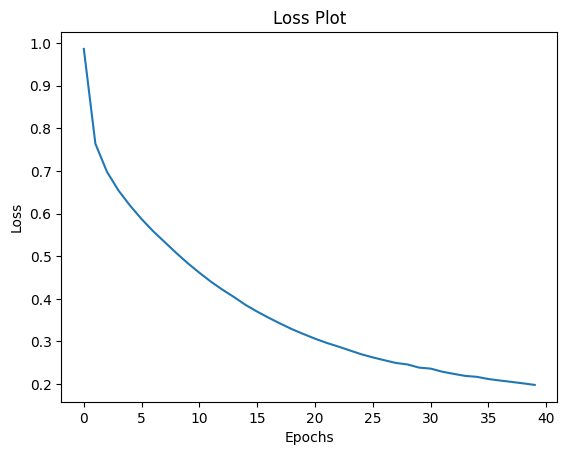

In [ ]:
EPOCHS = 40

for epoch in range(start_epoch, EPOCHS):
    start = time.time()
    total_loss = 0

    for (batch, (img_tensor, target)) in enumerate(dataset):
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss

        if batch % 100 == 0:
            print('Epoch {} Batch {} Loss {:.4f}'.format(
                epoch + 1, batch, batch_loss.numpy() / int(target.shape[1])))

    # Save the loss
    loss_plot.append(total_loss / num_steps)

    if epoch % 5 == 0:
        ckpt_manager.save()

    print('Epoch {} Loss {:.6f}'.format(epoch + 1,
                                        total_loss / num_steps))
    print('Time taken for 1 epoch {} sec\n'.format(time.time() - start))

# Display the training loss curve
plt.plot(loss_plot)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.show()

# 3.2 Test

In [ ]:
def evaluate(image):
    attention_plot = np.zeros((max_length, attention_features_shape))

    hidden = decoder.reset_state(batch_size=1)

    temp_input = tf.expand_dims(load_image(image)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    features = encoder(img_tensor_val)

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)

        attention_plot[i] = tf.reshape(attention_weights, (-1, )).numpy()

        predicted_id = tf.random.categorical(predictions, 1)[0][0].numpy()
        result.append(tokenizer.index_word[predicted_id])

        if tokenizer.index_word[predicted_id] == '<end>':
            return result, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    return result, attention_plot

# Function to visualize attention on the image
def plot_attention(image, result, attention_plot):
    temp_image = np.array(Image.open(image))

    fig = plt.figure(figsize=(10, 10))

    len_result = len(result)
    for l in range(len_result):
        temp_att = np.resize(attention_plot[l], (8, 8))
        ax = fig.add_subplot(len_result//2, len_result//2, l+1)
        ax.set_title(result[l])
        img = ax.imshow(temp_image)
        ax.imshow(temp_att, cmap='gray', alpha=0.6, extent=img.get_extent())

    plt.tight_layout()
    plt.show()


# Display of some examples using the result returned by the evaluation.


1762
10004
Real Caption: <start> a pastry with candles made to look like an animal <end>
Prediction Caption: a decorations with an art decorated like a teddy bear <end>


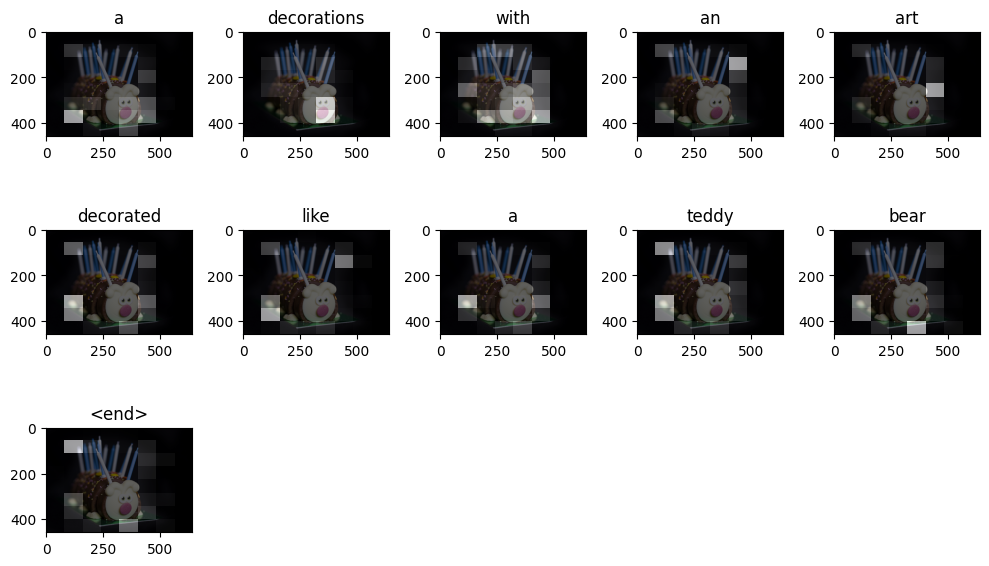

In [ ]:
# Display a few annotations from the test set
rid = np.random.randint(0, len(img_name_val))
image = img_name_val[rid]
print(rid)
print(len(cap_val))
real_caption = ' '.join([tokenizer.index_word[i] for i in cap_val[rid] if i not in [0]])
result, attention_plot = evaluate(image)

print('Real Caption:', real_caption)
print('Predicted Caption:', ' '.join(result))
plot_attention(image, result, attention_plot)


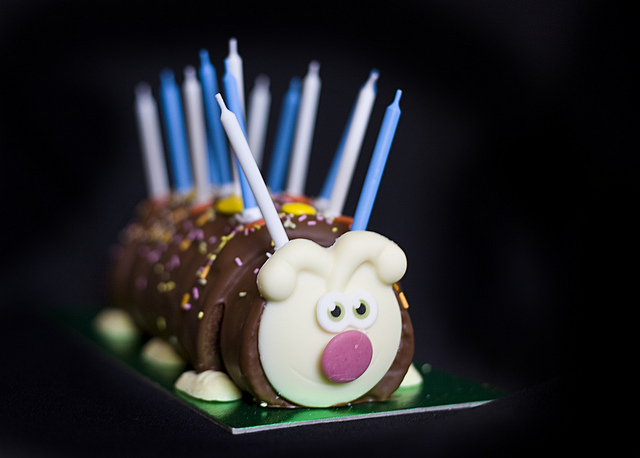

In [ ]:
Image.open(img_name_val[rid])